##  Bank Customer Churn prediction 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df  = pd.read_csv('customer_churn_dataset.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## Data Cleaning

In [ ]:
Replacing spaces with _ renaming columns droping unneceary columns types of data  sum of all null values sum of all duplicated 

In [4]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)

In [5]:
df.columns

Index(['rownumber', 'customerid', 'surname', 'creditscore', 'geography',
       'gender', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'exited', 'complain',
       'satisfaction_score', 'card_type', 'point_earned'],
      dtype='object')

In [6]:
df.rename(columns={
    'exited':'churn',
    'customerid':'customer_id',
    'hascrcard': 'has_cr_card',
    'creditscore':'credit_score',
    'numofproducts': 'number_of_products',
    'isactivemember': 'is_active_member',
    'estimatedsalary': 'estimated_salary',
}, inplace=True)

print(df.columns.tolist())

['rownumber', 'customer_id', 'surname', 'credit_score', 'geography', 'gender', 'age', 'tenure', 'balance', 'number_of_products', 'has_cr_card', 'is_active_member', 'estimated_salary', 'churn', 'complain', 'satisfaction_score', 'card_type', 'point_earned']


In [7]:
df.drop(columns=["rownumber", "surname","customer_id"], inplace=True)

In [8]:
df.columns

Index(['credit_score', 'geography', 'gender', 'age', 'tenure', 'balance',
       'number_of_products', 'has_cr_card', 'is_active_member',
       'estimated_salary', 'churn', 'complain', 'satisfaction_score',
       'card_type', 'point_earned'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   credit_score        10000 non-null  int64  
 1   geography           10000 non-null  object 
 2   gender              10000 non-null  object 
 3   age                 10000 non-null  int64  
 4   tenure              10000 non-null  int64  
 5   balance             10000 non-null  float64
 6   number_of_products  10000 non-null  int64  
 7   has_cr_card         10000 non-null  int64  
 8   is_active_member    10000 non-null  int64  
 9   estimated_salary    10000 non-null  float64
 10  churn               10000 non-null  int64  
 11  complain            10000 non-null  int64  
 12  satisfaction_score  10000 non-null  int64  
 13  card_type           10000 non-null  object 
 14  point_earned        10000 non-null  int64  
dtypes: float64(2), int64(10), object(3)
memory usage: 1.1+

In [10]:
df.dtypes

credit_score            int64
geography              object
gender                 object
age                     int64
tenure                  int64
balance               float64
number_of_products      int64
has_cr_card             int64
is_active_member        int64
estimated_salary      float64
churn                   int64
complain                int64
satisfaction_score      int64
card_type              object
point_earned            int64
dtype: object

In [11]:
df.isnull().sum()

credit_score          0
geography             0
gender                0
age                   0
tenure                0
balance               0
number_of_products    0
has_cr_card           0
is_active_member      0
estimated_salary      0
churn                 0
complain              0
satisfaction_score    0
card_type             0
point_earned          0
dtype: int64

In [12]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [13]:
df.describe()

,credit_score,age,tenure,balance,number_of_products,has_cr_card,is_active_member,estimated_salary,churn,complain,satisfaction_score,point_earned
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [14]:
df

,credit_score,geography,gender,age,tenure,balance,number_of_products,has_cr_card,is_active_member,estimated_salary,churn,complain,satisfaction_score,card_type,point_earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


##  EDA(Exploratory Data Analysis)

In [15]:
df.shape

(10000, 15)

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
credit_score,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
number_of_products,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
has_cr_card,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
is_active_member,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
estimated_salary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
churn,10000.0,0.203800,0.402842,0.00,0.00,0.000,0.0000,1.00
complain,10000.0,0.204400,0.403283,0.00,0.00,0.000,0.0000,1.00


In [17]:
# Credit score
df[df['credit_score'] < 300].count()
df[df['credit_score'] > 850].count()

# Age
df[df['age'] < 18].count()
df[df['age'] > 100].count()

# Tenure
df[df['tenure'] < 0].count()
df[df['tenure'] > 10].count()

# Balance
df[df['balance'] < 0].count()

# Number of products
df[df['number_of_products'] < 1].count()
df[df['number_of_products'] > 4].count()

# Satisfaction score
df[df['satisfaction_score'] < 1].count()
df[df['satisfaction_score'] > 5].count()

# Points earned
df[df['point_earned'] < 0].count()

# Estimated salary
df[df['estimated_salary'] <= 0].count()

credit_score          0
geography             0
gender                0
age                   0
tenure                0
balance               0
number_of_products    0
has_cr_card           0
is_active_member      0
estimated_salary      0
churn                 0
complain              0
satisfaction_score    0
card_type             0
point_earned          0
dtype: int64

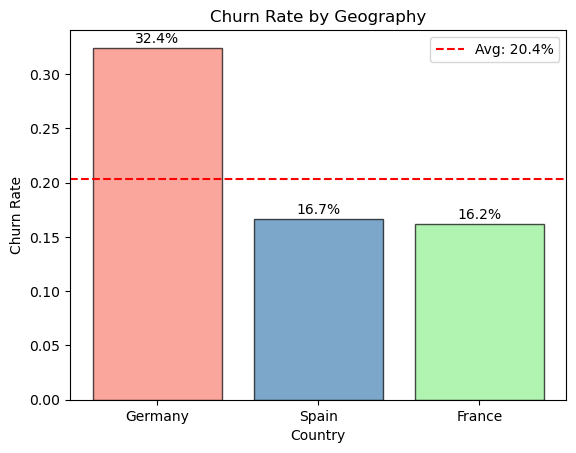

In [18]:
churn_rate = df.groupby('geography')['churn'].mean().sort_values(ascending=False)

bars = plt.bar(churn_rate.index, churn_rate.values,
               color=['salmon', 'steelblue', 'lightgreen'],
               edgecolor='black', alpha=0.7)

for bar, val in zip(bars, churn_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.1%}', ha='center', fontsize=10)

plt.axhline(df['churn'].mean(), color='red',
            linestyle='--', label=f'Avg: {df["churn"].mean():.1%}')

plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate')
plt.xlabel('Country')
plt.legend()
plt.show()

In [19]:
print(df['has_cr_card'].unique())
print(df['is_active_member'].unique())
print(df['churn'].unique())

[1 0]
[1 0]
[1 0]


In [20]:
print(df['geography'].unique())
print(df['gender'].unique())
print(df['card_type'].unique())

['France' 'Spain' 'Germany']
['Female' 'Male']
['DIAMOND' 'GOLD' 'SILVER' 'PLATINUM']


In [21]:
churn_counts = df['churn'].value_counts()
churn_rate = df['churn'].value_counts(normalize=True)

print(churn_counts)
print(churn_rate)

churn
0    7962
1    2038
Name: count, dtype: int64
churn
0    0.7962
1    0.2038
Name: proportion, dtype: float64


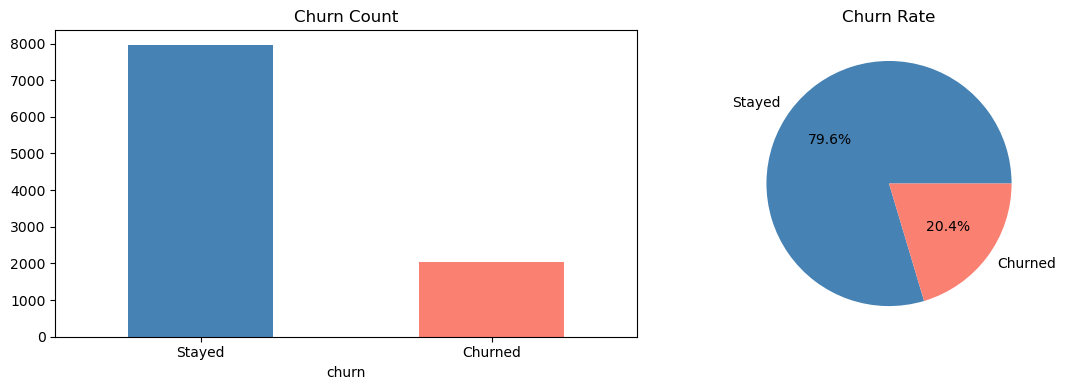

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Churn Count')
axes[0].set_xticklabels(['Stayed', 'Churned'], rotation=0)

axes[1].pie(churn_counts, labels=['Stayed', 'Churned'], 
            autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[1].set_title('Churn Rate')

plt.tight_layout()
plt.show()

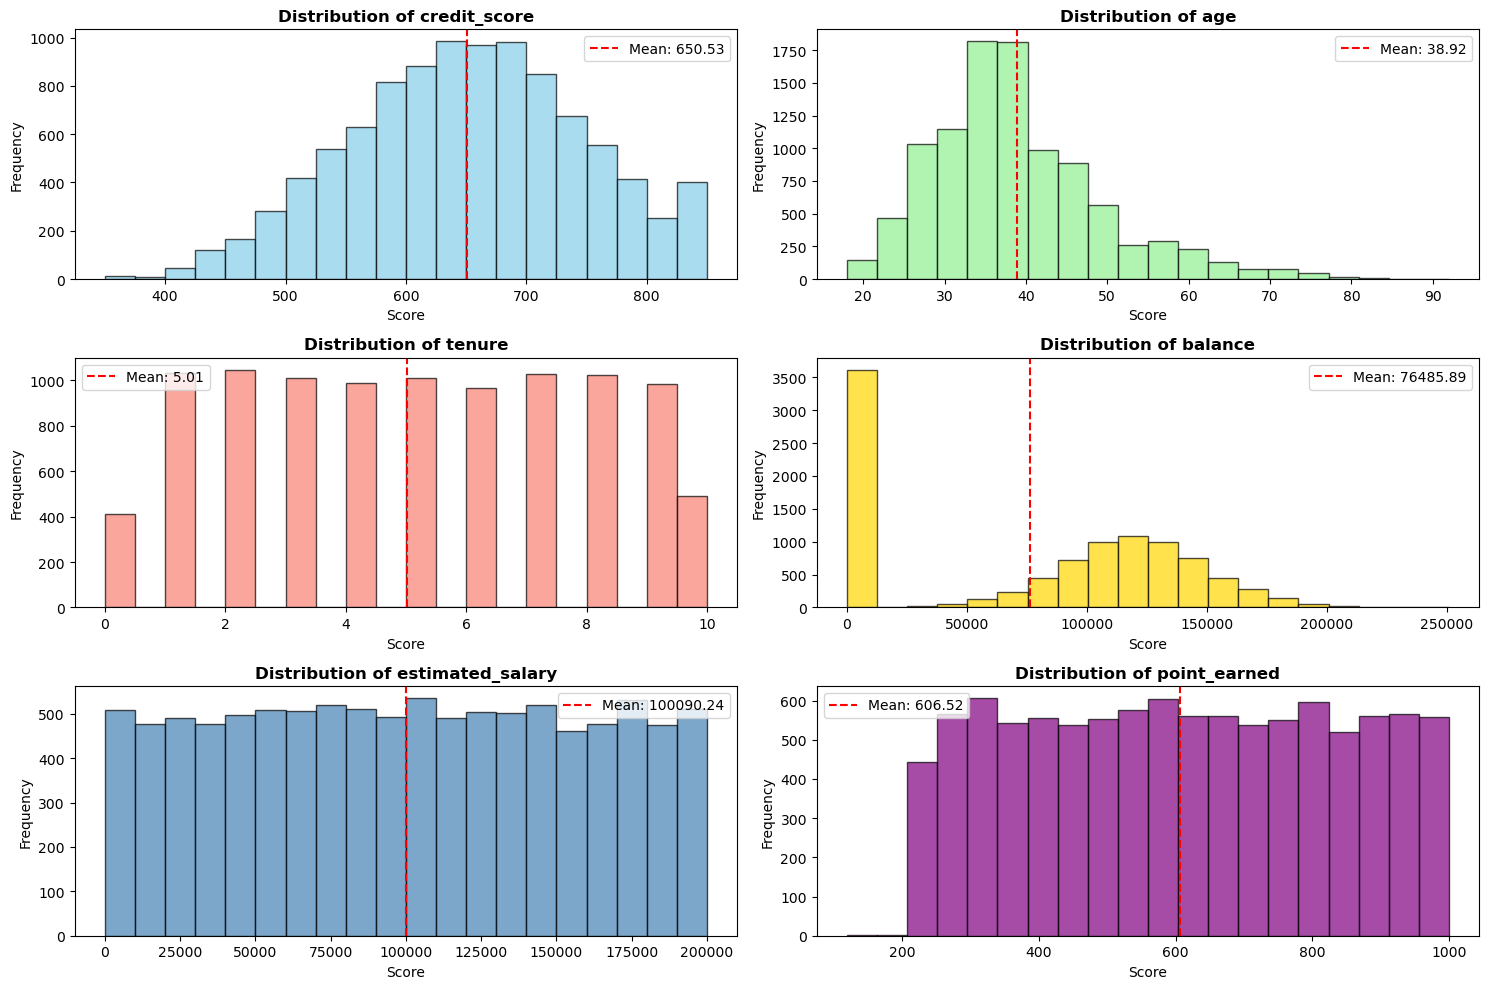

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
scores = ['credit_score', 'age', 'tenure', 'balance','estimated_salary','point_earned']
colors = ['skyblue', 'lightgreen', 'salmon', 'gold','steelblue','purple']

for idx, (score, color) in enumerate(zip(scores, colors)):
    ax = axes[idx//2, idx%2]
    ax.hist(df[score], bins=20, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {score}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.axvline(df[score].mean(), color='red', linestyle='--', label=f'Mean: {df[score].mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.show()


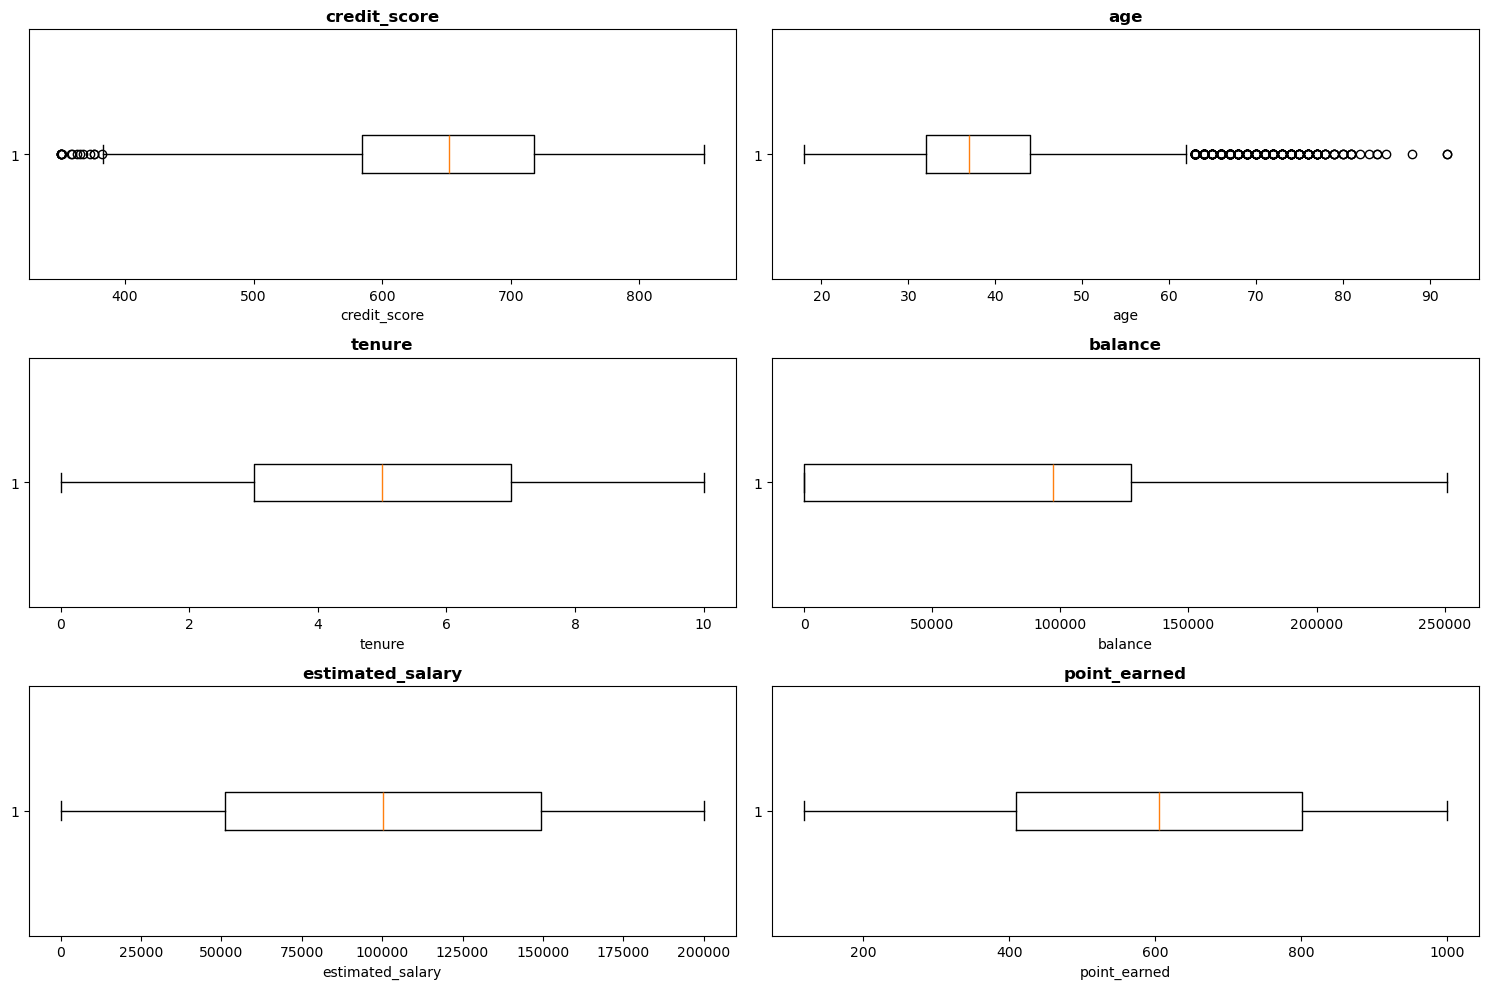

In [24]:
nums = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'point_earned']
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

for idx, col in enumerate(nums):
    ax = axes[idx//2, idx%2]
    ax.boxplot(df[col], vert=False)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

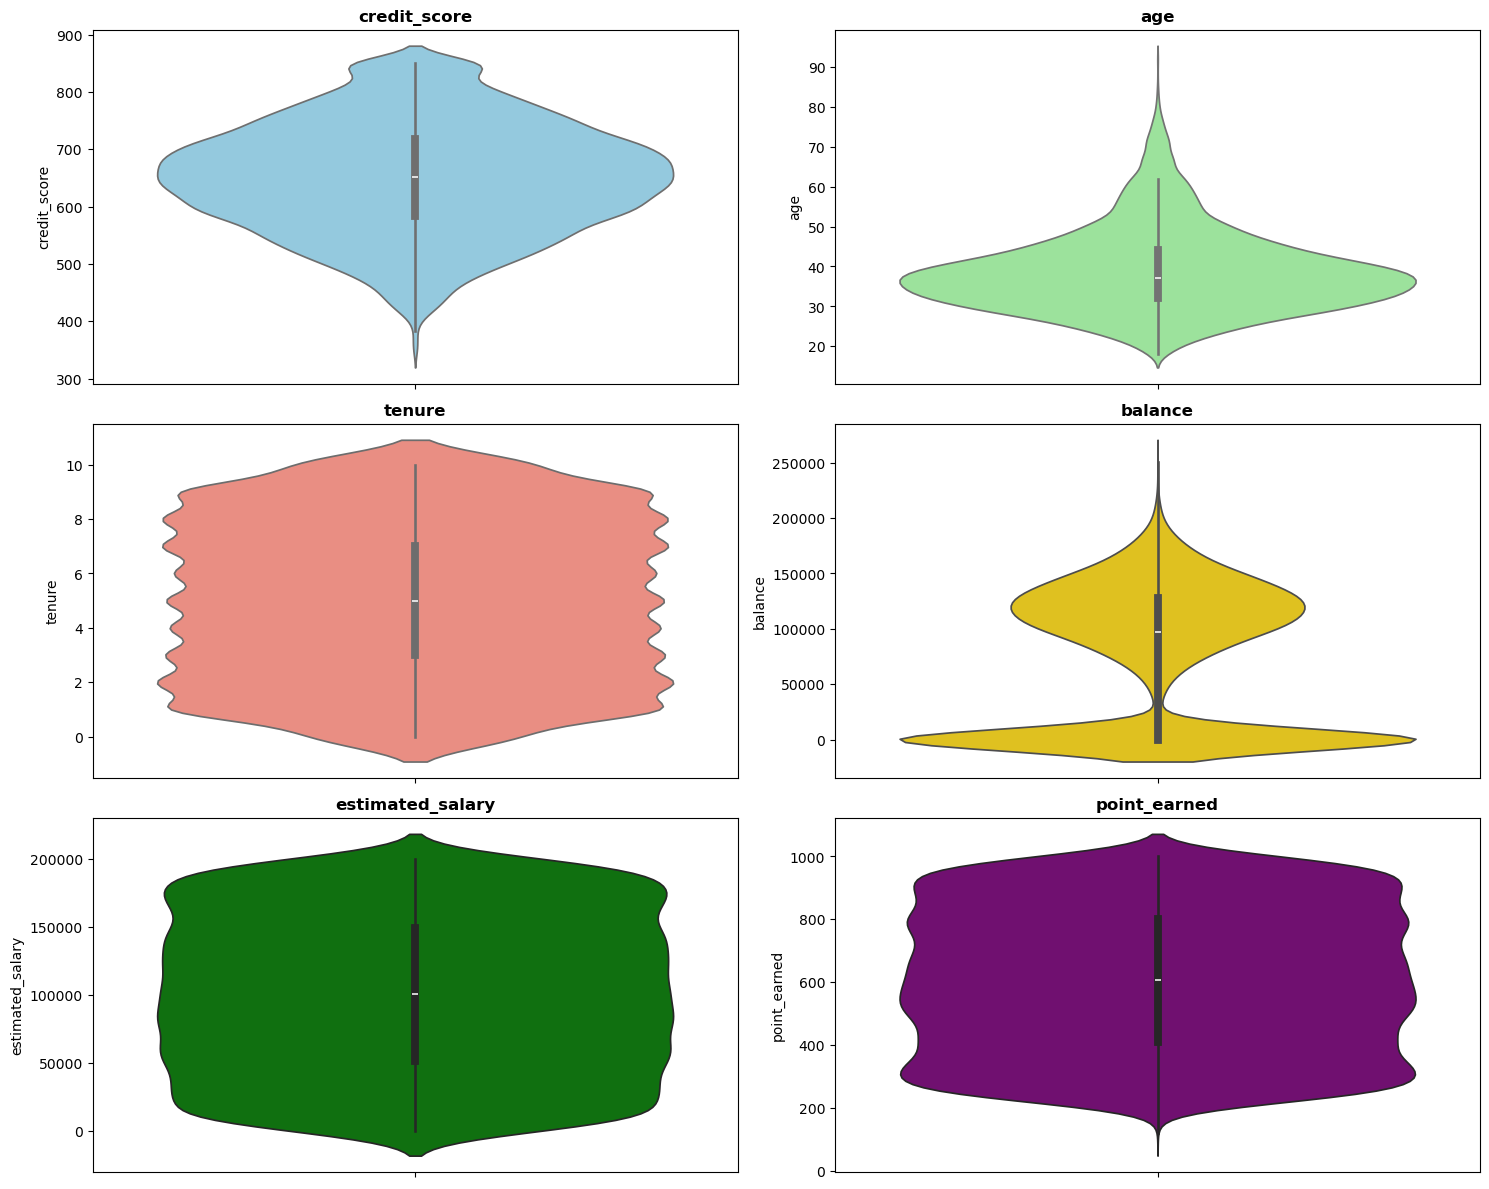

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
nums = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'point_earned']
colors = ['skyblue', 'lightgreen', 'salmon', 'gold', 'green', 'purple']

for idx, (col, color) in enumerate(zip(nums, colors)):
    ax = axes[idx//2, idx%2]
    sns.violinplot(data=df, y=col, ax=ax, color=color)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [26]:
df['zero_balance'] = (df['balance'] == 0).astype(int)

In [27]:
zero = (df['balance'] == 0).sum()
total = len(df)

print(f"Zero balance customers: {zero} ({zero/total:.1%})")
print(f"Non-zero balance customers: {total-zero} ({(total-zero)/total:.1%})")

Zero balance customers: 3617 (36.2%)
Non-zero balance customers: 6383 (63.8%)


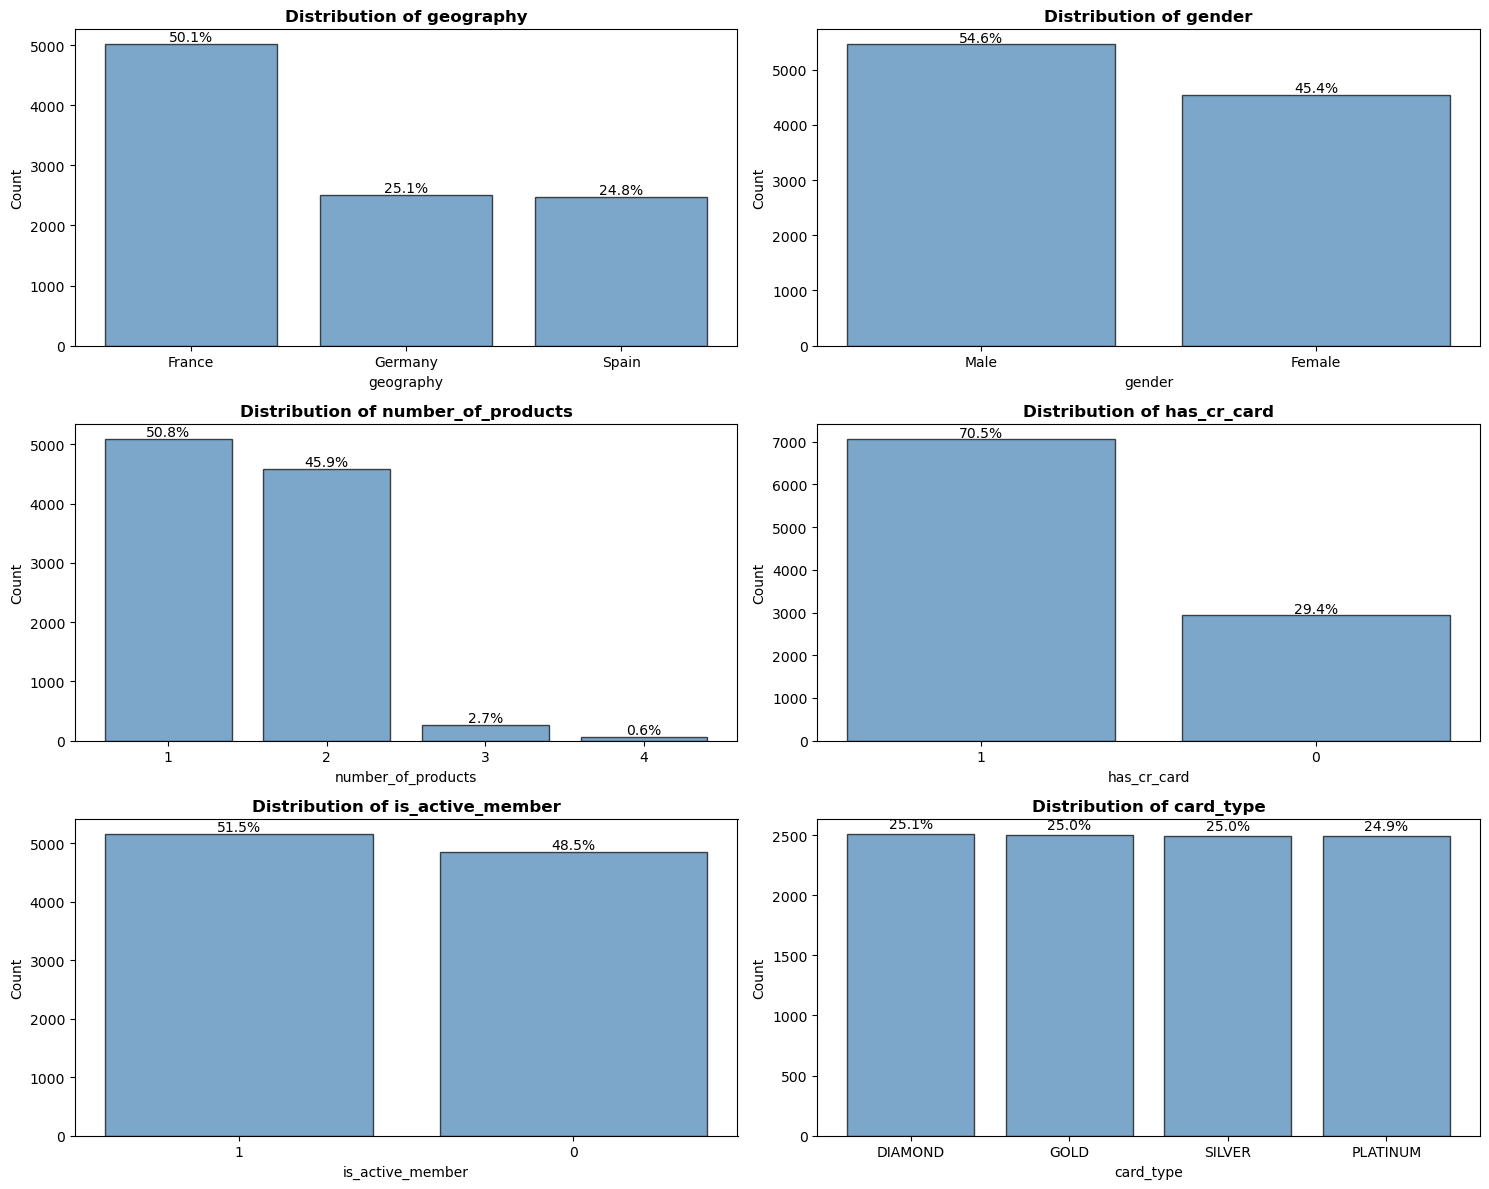

In [28]:
cats = ['geography', 'gender', 'number_of_products', 
        'has_cr_card', 'is_active_member', 'card_type']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for idx, col in enumerate(cats):
    ax = axes[idx//2, idx%2]
    
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    
    bars = ax.bar(counts.index.astype(str), counts.values, 
                  color='steelblue', edgecolor='black', alpha=0.7)
    
    # Add percentage labels on bars
    for bar, pct in zip(bars, percentages.values):
        ax.text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 50,
                f'{pct:.1f}%', ha='center', fontsize=10)
    
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

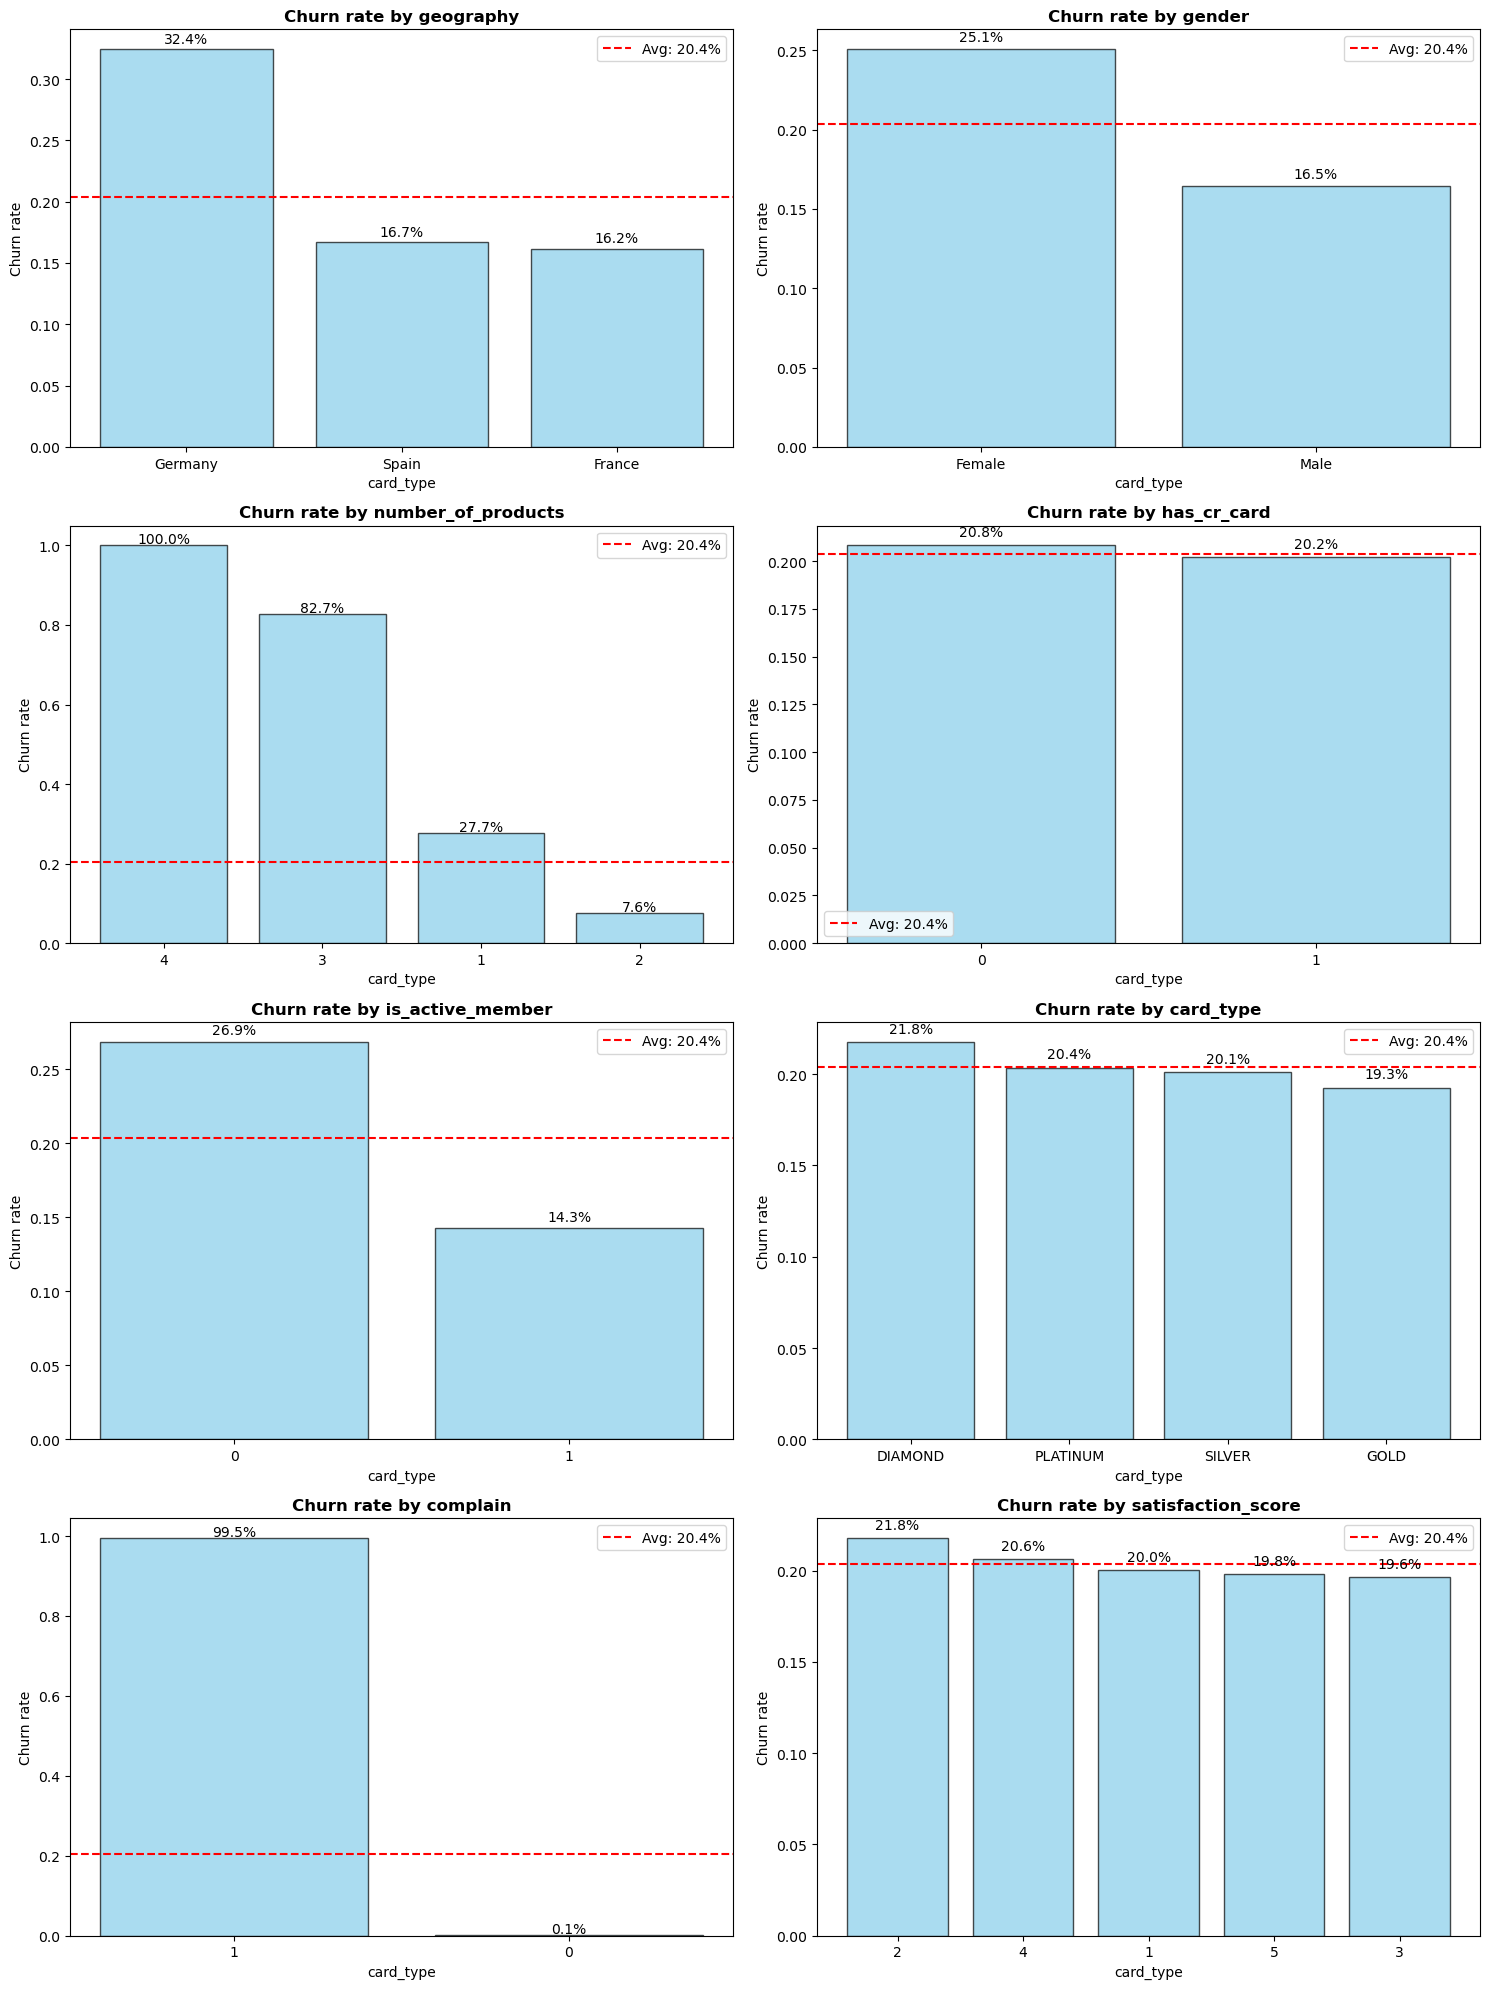

In [29]:
features = ['geography', 'gender', 'number_of_products',
        'has_cr_card', 'is_active_member', 'card_type',
        'complain', 'satisfaction_score']

fig, axes = plt.subplots(4, 2, figsize=(15, 20))

for idx,feature in enumerate(features):
    ax = axes[idx//2, idx%2]
    
    churn_rate = df.groupby(feature)['churn'].mean().sort_values(ascending=False)
    
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values,
                  color='skyblue', edgecolor='black', alpha=0.7)
    
    # Add percentage labels
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.1%}', ha='center', fontsize=10)
    
    # Overall churn rate reference line
    ax.axhline(df['churn'].mean(), color='red', 
               linestyle='--', label=f'Avg: {df["churn"].mean():.1%}')
    
    ax.set_title(f'Churn rate by {feature}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn rate')
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [30]:
df.groupby('churn')['age'].mean()

churn
0    37.408063
1    44.835623
Name: age, dtype: float64

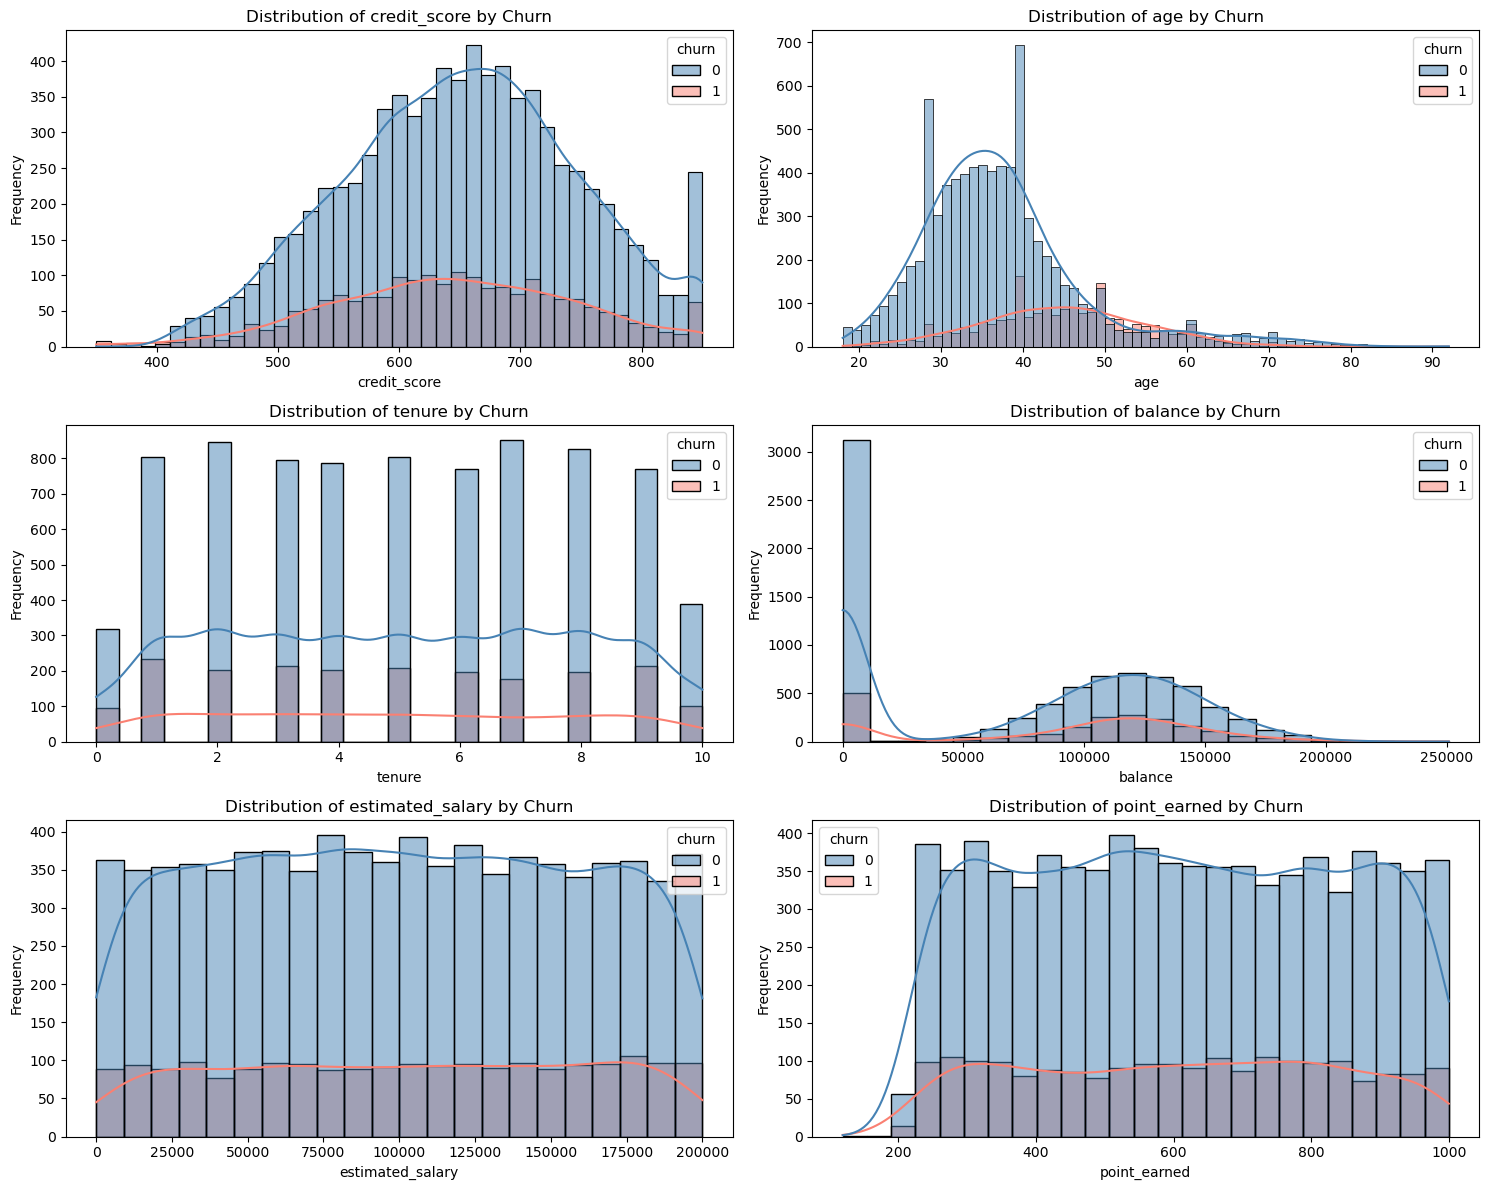

      credit_score               age           tenure              balance  \
              mean median       mean median      mean median          mean   
churn                                                                        
0       651.837855  653.0  37.408063   36.0  5.032781    5.0  72742.750663   
1       645.414622  646.0  44.835623   45.0  4.934740    5.0  91109.476006   

                 estimated_salary             point_earned         
          median             mean      median         mean median  
churn                                                              
0       92063.06     99726.853141   99620.355   607.044084  603.0  
1      109344.23    101509.908783  102489.335   604.448479  610.5  


In [31]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

numerical_columns = ['credit_score', 'age', 'tenure', 
                     'balance', 'estimated_salary', 'point_earned']

for idx, column in enumerate(numerical_columns):
    ax = axes[idx//2, idx%2]
    
    sns.histplot(data=df, x=column, hue='churn',
                 common_norm=False, kde=True,
                 palette=['steelblue', 'salmon'],
                 ax=ax)
    
    ax.set_title(f'Distribution of {column} by Churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Summary table — run separately
print(df.groupby('churn')[numerical_columns].agg(['mean', 'median']))

In [32]:
cols_to_drop = ['complain', 'estimated_salary', 
                'card_type', 'has_cr_card', 
                'satisfaction_score']

df.drop(columns=cols_to_drop, inplace=True)

print(df.shape)
print(df.columns.tolist())

(10000, 11)
['credit_score', 'geography', 'gender', 'age', 'tenure', 'balance', 'number_of_products', 'is_active_member', 'churn', 'point_earned', 'zero_balance']


In [33]:
df['age_bin'] = pd.cut(df['age'],
                       bins=[0, 30, 40, 50, 60, 100],
                       labels=['<30', '30s', '40s', '50s', '60+'])

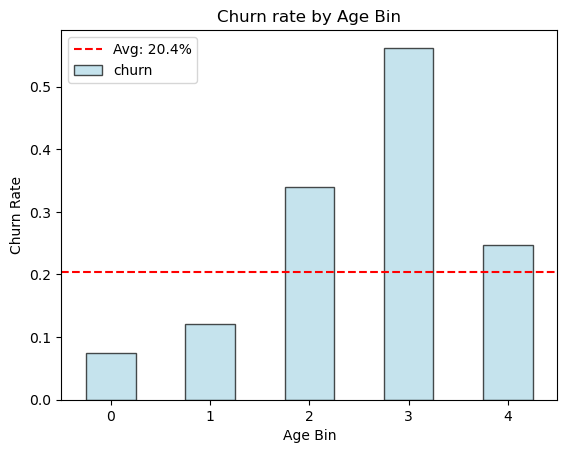

In [83]:
df.groupby('age_bin')['churn'].mean().plot(kind='bar', 
                                            color='lightblue',
                                            edgecolor='black',
                                            alpha=0.7)

plt.axhline(df['churn'].mean(), color='red', 
            linestyle='--', label=f'Avg: {df["churn"].mean():.1%}')

plt.title('Churn rate by Age Bin')
plt.xlabel('Age Bin')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.legend()
plt.show()

## Feature Engineering

In [35]:
df['active_with_balance'] = (
    (df['is_active_member'] == 1) & 
    (df['balance'] > 0)
).astype(int)

In [36]:
df['inactive_zero_balance'] = (
    (df['is_active_member'] == 0) & 
    (df['balance'] == 0)
).astype(int)

In [37]:
df['active_zero_balance'] = (
    (df['is_active_member'] == 1) & 
    (df['balance'] == 0)
).astype(int)

In [38]:
df['inactive_with_balance'] = (
    (df['is_active_member'] == 0) & 
    (df['balance'] == 1)
).astype(int)

In [39]:
df['products_anomaly'] = (
    df['number_of_products'] >= 3
).astype(int)

In [40]:
df['germany_inactive'] = (
    (df['geography'] == 'Germany') & 
    (df['is_active_member'] == 0)
).astype(int)

In [41]:
df['balance_per_product'] = (
    df['balance'] / df['number_of_products']
)

In [42]:
new_features = ['active_with_balance', 'inactive_zero_balance',
                'active_zero_balance','inactive_with_balance',
                'products_anomaly',  'germany_inactive',
                'balance_per_product']

print(df.groupby('churn')[new_features].mean())

       active_with_balance  inactive_zero_balance  active_zero_balance  \
churn                                                                    
0                 0.341999               0.178850             0.212635   
1                 0.272326               0.157017             0.088322   

       inactive_with_balance  products_anomaly  germany_inactive  \
churn                                                              
0                        0.0          0.005777          0.093318   
1                        0.0          0.137390          0.254171   

       balance_per_product  
churn                       
0             59667.931331  
1             75132.932305  


In [43]:
print(df.columns.tolist())

['credit_score', 'geography', 'gender', 'age', 'tenure', 'balance', 'number_of_products', 'is_active_member', 'churn', 'point_earned', 'zero_balance', 'age_bin', 'active_with_balance', 'inactive_zero_balance', 'active_zero_balance', 'inactive_with_balance', 'products_anomaly', 'germany_inactive', 'balance_per_product']


In [44]:
cols_to_drop = ['active_with_balance','inactive_with_balance','inactive_zero_balance','balance_per_product']

df.drop(columns=cols_to_drop, inplace=True)

print(df.shape)
print(df.columns.tolist())

(10000, 15)
['credit_score', 'geography', 'gender', 'age', 'tenure', 'balance', 'number_of_products', 'is_active_member', 'churn', 'point_earned', 'zero_balance', 'age_bin', 'active_zero_balance', 'products_anomaly', 'germany_inactive']


## Encoding

In [45]:
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

In [46]:
age_order = {'<30': 0, '30s': 1, '40s': 2, '50s': 3, '60+': 4}
df['age_bin'] = df['age_bin'].map(age_order).astype(int)

In [47]:
df = pd.get_dummies(df, columns=['geography'], drop_first=True).astype(int)

In [48]:
df

,credit_score,gender,age,tenure,balance,number_of_products,is_active_member,churn,point_earned,zero_balance,age_bin,active_zero_balance,products_anomaly,germany_inactive,geography_Germany,geography_Spain
0,619,1,42,2,0,1,1,1,464,1,2,1,0,0,0,0
1,608,1,41,1,83807,1,1,0,456,0,2,0,0,0,0,1
2,502,1,42,8,159660,3,0,1,377,0,2,0,1,0,0,0
3,699,1,39,1,0,2,0,0,350,1,1,0,0,0,0,0
4,850,1,43,2,125510,1,1,0,425,0,2,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,39,5,0,2,0,0,300,1,1,0,0,0,0,0
9996,516,0,35,10,57369,1,1,0,771,0,1,0,0,0,0,0
9997,709,1,36,7,0,1,1,1,564,1,1,1,0,0,0,0
9998,772,0,42,3,75075,2,0,1,339,0,2,0,0,1,1,0


In [49]:
print(df.dtypes)
print(df.shape)
print(df.columns.tolist())

credit_score           int64
gender                 int64
age                    int64
tenure                 int64
balance                int64
number_of_products     int64
is_active_member       int64
churn                  int64
point_earned           int64
zero_balance           int64
age_bin                int64
active_zero_balance    int64
products_anomaly       int64
germany_inactive       int64
geography_Germany      int64
geography_Spain        int64
dtype: object
(10000, 16)
['credit_score', 'gender', 'age', 'tenure', 'balance', 'number_of_products', 'is_active_member', 'churn', 'point_earned', 'zero_balance', 'age_bin', 'active_zero_balance', 'products_anomaly', 'germany_inactive', 'geography_Germany', 'geography_Spain']


##  Train/Test Split

In [50]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppresses INFO and WARNING messages

In [52]:
X = df.drop(columns=['churn'])
y = df['churn']

print(X.shape)  # (10000, 15)
print(y.shape)  # (10000,)

(10000, 15)
(10000,)


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)  # (8000, 15)
print(X_test.shape)   # (2000, 15)

(8000, 15)
(2000, 15)


In [54]:
print(f"Train churn rate: {y_train.mean():.1%}")
print(f"Test churn rate:  {y_test.mean():.1%}")

Train churn rate: 20.4%
Test churn rate:  20.4%


## Scaling

In [55]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

In [56]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [57]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.93      0.78      0.85      1592
           1       0.47      0.77      0.58       408

    accuracy                           0.78      2000
   macro avg       0.70      0.77      0.71      2000
weighted avg       0.84      0.78      0.79      2000

ROC-AUC: 0.8503


In [58]:
scaler.fit_transform(X_train)  # learns mean and std from train
scaler.transform(X_test)       # applies train's mean and std to test

array([[-0.44108724,  1.10247575, -0.08787439, ..., -0.38076704,
         1.72629647, -0.57484841],
       [ 0.36561412, -0.90704943, -0.18263043, ..., -0.38076704,
        -0.57927478, -0.57484841],
       [ 0.01397507,  1.10247575,  0.29114979, ..., -0.38076704,
        -0.57927478,  1.73958906],
       ...,
       [-0.23424074,  1.10247575,  0.57541792, ...,  2.62627772,
         1.72629647, -0.57484841],
       [ 1.30676572,  1.10247575, -0.84592274, ..., -0.38076704,
        -0.57927478, -0.57484841],
       [-0.23424074, -0.90704943,  0.00688166, ..., -0.38076704,
        -0.57927478, -0.57484841]], shape=(2000, 15))

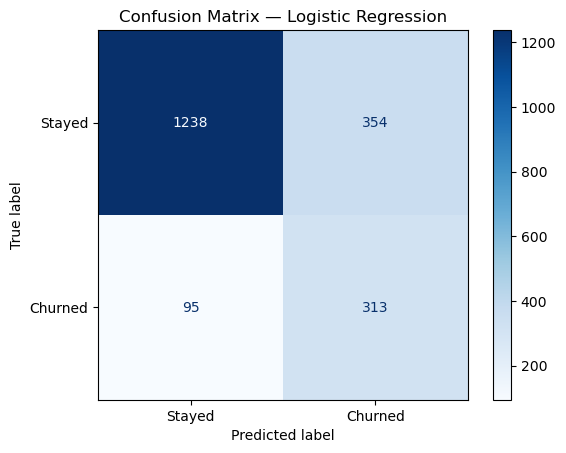

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

In [60]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

scale_pos_weight: 3.91
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1592
           1       0.57      0.67      0.62       408

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000

ROC-AUC: 0.8631


## Threshold Tuning

In [61]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("="*48)

for thresh in thresholds:
    y_pred_thresh = (y_prob_xgb >= thresh).astype(int)
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    print(f"{thresh:<12} {p:<12.3f} {r:<12.3f} {f:<12.3f}")

Threshold    Precision    Recall       F1          
0.3          0.469        0.799        0.591       
0.35         0.485        0.757        0.591       
0.4          0.525        0.735        0.613       
0.45         0.552        0.706        0.619       
0.5          0.573        0.672        0.619       
0.55         0.596        0.645        0.620       
0.6          0.638        0.623        0.630       


In [62]:
y_pred_final = (y_prob_xgb >= 0.45).astype(int)

In [63]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("="*48)

for thresh in thresholds:
    y_pred_thresh = (y_prob_xgb >= 0.45).astype(int)
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    print(f"{thresh:<12} {p:<12.3f} {r:<12.3f} {f:<12.3f}")

Threshold    Precision    Recall       F1          
0.3          0.552        0.706        0.619       
0.35         0.552        0.706        0.619       
0.4          0.552        0.706        0.619       
0.45         0.552        0.706        0.619       
0.5          0.552        0.706        0.619       
0.55         0.552        0.706        0.619       
0.6          0.552        0.706        0.619       


In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("="*48)

for thresh in thresholds:
    y_pred_thresh = (y_prob_xgb >= thresh).astype(int)
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    print(f"{thresh:<12} {p:<12.3f} {r:<12.3f} {f:<12.3f}")

Threshold    Precision    Recall       F1          
0.3          0.469        0.799        0.591       
0.35         0.485        0.757        0.591       
0.4          0.525        0.735        0.613       
0.45         0.552        0.706        0.619       
0.5          0.573        0.672        0.619       
0.55         0.596        0.645        0.620       
0.6          0.638        0.623        0.630       


In [65]:
y_pred_final = (y_prob_xgb >= 0.45).astype(int)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1592
           1       0.55      0.71      0.62       408

    accuracy                           0.82      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000



## Hyperparameter Tuning

In [66]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [3.91]
}

xgb_tuned = XGBClassifier(
    random_state=42,
    eval_metric='aucpr'
)

search = RandomizedSearchCV(
    xgb_tuned,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters:
{'subsample': 0.6, 'scale_pos_weight': 3.91, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.9}


In [75]:
xgb_tuned = XGBClassifier(
    subsample=0.6,
    scale_pos_weight=3.91,
    n_estimators=300,
    max_depth=7,
    learning_rate=0.01,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='aucpr'
)

xgb_tuned.fit(X_train, y_train)

y_pred_tuned = xgb_tuned.predict(X_test)
y_prob_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_tuned))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

              precision    recall  f1-score   support

           0       0.93      0.85      0.89      1592
           1       0.56      0.74      0.64       408

    accuracy                           0.83      2000
   macro avg       0.74      0.80      0.76      2000
weighted avg       0.85      0.83      0.84      2000

ROC-AUC: 0.8789


##  SHAP Values

In [76]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


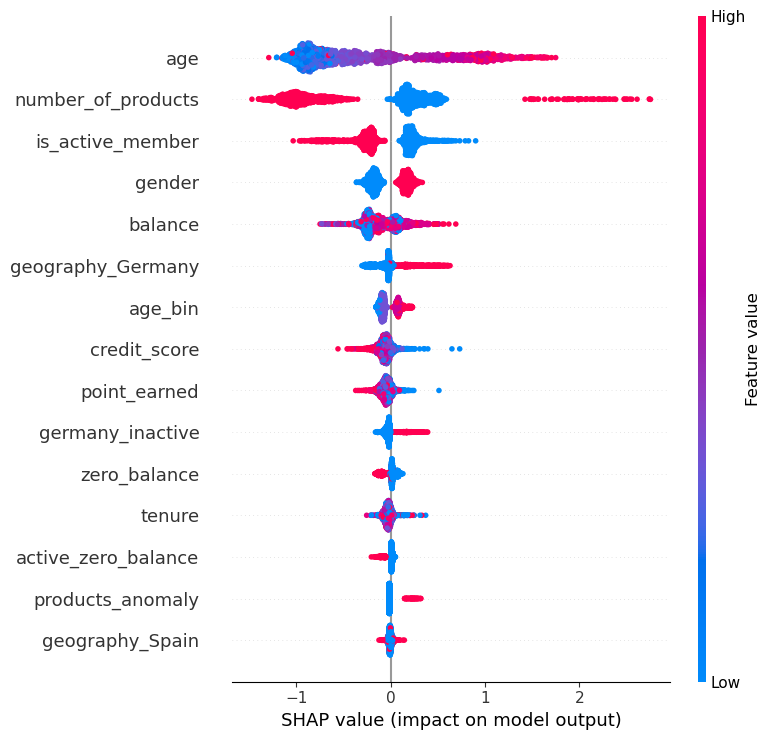

In [77]:
import shap

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test, 
                  feature_names=X_test.columns)

In [78]:
df['churn_probability'] = xgb_tuned.predict_proba(X)[:, 1]
df['churn_prediction'] = (df['churn_probability'] >= 0.45).astype(int)

# Rank by highest risk first
df_sorted = df.sort_values('churn_probability', ascending=False)

# Top 200 highest risk customers
high_risk = df_sorted.head(200)

print(f"Total customers scored: {len(df)}")
print(f"Predicted churners: {df['churn_prediction'].sum()}")
print(f"\nTop 10 highest risk customers:")
print(high_risk[['churn_probability', 'churn_prediction']].head(10))

Total customers scored: 10000
Predicted churners: 3106

Top 10 highest risk customers:
      churn_probability  churn_prediction
2614           0.967209                 1
4054           0.965959                 1
8923           0.965805                 1
1265           0.965451                 1
6255           0.965252                 1
9438           0.965252                 1
4992           0.964620                 1
7248           0.964258                 1
6279           0.964155                 1
6911           0.963969                 1


In [79]:
df['risk_tier'] = pd.cut(df['churn_probability'],
                          bins=[0, 0.3, 0.5, 0.7, 1.0],
                          labels=['Low', 'Medium', 'High', 'Critical'])

print(df['risk_tier'].value_counts())

risk_tier
Low         5464
Medium      1817
Critical    1528
High        1191
Name: count, dtype: int64


In [81]:
# Critical customers only
critical = df[df['risk_tier'] == 'Critical']
print(f"Critical customers: {len(critical)}")

# Save tiered list
df[['churn_probability', 'risk_tier']].sort_values(
    'churn_probability', ascending=False
).to_csv('churn_predictions_tiered.csv')

Critical customers: 1528


# Conclusion

## What Was Built
A complete end to end machine learning system that predicts which bank customers will leave before they actually leave. The system scores all 10,000 customers monthly, ranks them by churn risk, and delivers a prioritized action list to the retention team.

---


### Technical Results
| Model | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 0.47 | 0.77 | 0.58 | 0.8503 |
| Random Forest | 0.77 | 0.47 | 0.58 | 0.8563 |
| XGBoost Default | 0.57 | 0.67 | 0.62 | 0.8631 |
| **XGBoost Tuned** | **0.56** | **0.74** | **0.64** | **0.8789** |

The final tuned XGBoost model correctly identifies **74% of churners** before they leave with a ROC-AUC of **0.8789** — meaning the model ranks a churner above a non-churner 88% of the time.

### Business Results
| Tier | Count | Action |
|---|---|---|
| Critical (70–100%) | 1,528 |
| High (50–70%) | 1,191 | 
| Medium (30–50%) | 1,817 | 
| Low (0–30%) | 5,464 | 

---

## What the Data Revealed

### Strongest Predictors of Churn
1. **Age** — older customers churn significantly more, especially the 40–60 age group
2. **Active membership** — inactive customers churn at double the rate of active ones
3. **Number of products** — customers with 3–4 products show near 100% churn, a clear anomaly
4. **Geography** — German customers churn at 32.4% vs 16% for France and Spain
5. **Balance** — zero balance customers have no financial commitment and leave more easily

### Weakest Predictors 
- `credit_score` — almost identical distribution for churners and non-churners
- `estimated_salary` — perfectly uniform, zero predictive power
- `tenure` — years with the bank does not protect against churn
- `has_cr_card` — only 0.6% difference between groups

---

## The Most Important Finding

The features that  intuitively expected to matter most in banking — credit score, salary, tenure — turned out to be the weakest predictors. Whether a customer actively uses their account was far more predictive than how much money they earn or how long they have been a customer.

 They file a complaint it is already too late — the complaint column showed a 99.5% churn rate, confirming that complaints are recorded at the point of leaving, not before.

---

## What This Means for the Bank

The bank needs to shift from **reactive** to **proactive** retention:

The bank should act before complaints arise, as waiting means customers have already decided to leave. By monitoring early activity signals — such as declining transactions, zero balance growth, and lack of new product adoption. — the bank can identify at-risk customers. Retention efforts should focus on enhancing  their experience , since churn is driven by low account activity rather than price.

---


## Business Value

```
Catching 74% of churners → 302 out of 408 in test set

If retention team saves 20% of Critical customers:
1,528 × 20% = 305 customers retained
At $1,000 revenue per customer per year
= $305,000 saved annually
```

---
